# Access Sentinel-3 in Native Mode

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-3** EOPF Zarr products in **native mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).

- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

---

## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import matplotlib.pyplot as plt
import pystac_client
import xarray as xr

---

## Open a Sentinel-3 OLCI L1 EFR

We begin with an example that accesses a Sentinel-3 OLCI L1 EFR product in **native mode**. 

### Find a Sentinel-3 OLCI L1 EFR Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-efr) to search for a Sentinel-3 OLCI Level-1 EFR tile.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-efr"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-13", "2026-03-13"],
    ).items()
)
items

[<Item id=S3B_OL_1_EFR____20260313T100048_20260313T100348_20260313T120352_0179_117_350_2160_ESA_O_NR_004>,
 <Item id=S3B_OL_1_EFR____20260313T100048_20260313T100348_20260314T100820_0180_117_350_2160_ESA_O_NT_004>]

Next, we can inspect the item’s contents. The asset `"product"` links to the entire Zarr store. The additional field `xarray:open_datatree_kwargs` has been included in the asset `"product"`, which provides the arguments needed to open the product using Xarray’s `eopf-zarr` engine.

In [3]:
item = items[1]
item

<Item id=S3B_OL_1_EFR____20260313T100048_20260313T100348_20260314T100820_0180_117_350_2160_ESA_O_NT_004>

### Open Sentinel-3 OLCI L1 EFR as DataTree

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [4]:
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:    (rows: 4091, columns: 77)
│   │       Coordinates:
│   │           latitude   (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           longitude  (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           oaa        (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           oza        (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           saa        (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           sza        (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   ├── Group: /conditions/image
│   │       Dimensions:         (rows: 4091, columns: 4865)
│   │       Coordinates:
│   │           time_stamp      (rows) datetime64[ns] 33kB dask.array<chunksize=(1024,), meta=np.ndarray>
│   │           altitude        (rows, columns) int16 40MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │           latitude        (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │           longitude       (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           detector_index  (rows, columns) float32 80MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │           frame_offset    (rows, columns) float32 80MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   ├── Group: /conditions/instrument
│   │       Dimensions:                       (bands: 21, detectors: 3700, bands2: 21)
│   │       Coordinates:
│   │         * detectors                     (detectors) int64 30kB 0 1 2 ... 3698 3699
│   │       Dimensions without coordinates: bands, bands2
│   │       Data variables:
│   │           fwhm                          (bands, detectors) float32 311kB dask.array<chunksize=(21, 3700), meta=np.ndarray>
│   │           lambda0                       (bands, detectors) float32 311kB dask.array<chunksize=(21, 3700), meta=np.ndarray>
│   │           relative_spectral_covariance  (bands, bands2) float32 2kB dask.array<chunksize=(21, 21), meta=np.ndarray>
│   │           solar_flux                    (bands, detectors) float32 311kB dask.array<chunksize=(21, 3700), meta=np.ndarray>
│   ├── Group: /conditions/meteorology
│   │       Dimensions:                          (pressure_level: 25, rows: 4091,
│   │                                             columns: 77, wind_vector: 2)
│   │       Coordinates:
│   │         * pressure_level                   (pressure_level) int64 200B 0 1 2 ... 23 24
│   │           latitude                         (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           longitude                        (rows, columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │         * wind_vector                      (wind_vector) int64 16B 0 1
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           atmospheric_temperature_profile  (pressure_level, rows, columns) float32 32MB dask.array<chunksize=(9, 1024, 77), meta=np.ndarray>
│   │           horizontal_wind                  (wind_vector, rows, columns) float32 3MB dask.array<chunksize=(2, 1024, 77), meta=np.ndarray>
│   │           humidity                         (rows, columns) float32 1MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           sea_level_pressure               (rows, columns) float32 1MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           total_columnar_water_vapour      (rows, columns) float32 1MB dask.array<chunksize=(1024, 77), me

As an example, we plot the **red band** (`oa08_radiance`), which will trigger loading and visualization of the data. We also plot the 2D **curvilinear latitude and longitude grids**, which can be used for geolocation.  

> **Note:** To speed up rendering of large datasets in Matplotlib, we plot the data at a lower resolution (every 4th pixel).

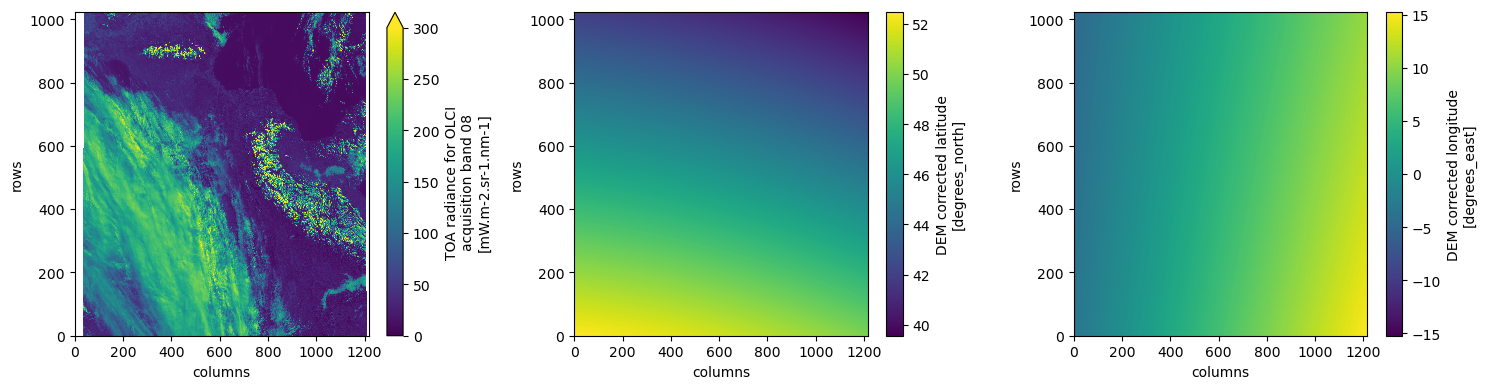

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
dt.measurements.oa08_radiance[::4, ::4].plot.imshow(ax=ax[0], vmin=0, vmax=300)
dt.measurements.latitude[::4, ::4].plot.imshow(ax=ax[1], cmap="viridis")
dt.measurements.longitude[::4, ::4].plot.imshow(ax=ax[2], cmap="viridis")
plt.tight_layout()

### Open Sentinel-3 OLCI L1 EFR Radiance Group as Dataset

We can directly access the individual reflectance group (`radianceData`) as `xarray.Dataset` objects. The opening parameters are stored in the asset’s extra field `"xarray:open_dataset_kwargs"`. 

In [6]:
ds = xr.open_dataset(
    item.assets["radianceData"].href,
    **item.assets["radianceData"].extra_fields["xarray:open_dataset_kwargs"],
)
ds

<xarray.Dataset> Size: 4GB
Dimensions:        (rows: 4091, columns: 4865)
Coordinates:
    time_stamp     (rows) datetime64[ns] 33kB dask.array<chunksize=(1024,), meta=np.ndarray>
    altitude       (rows, columns) int16 40MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    latitude       (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    longitude      (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Dimensions without coordinates: rows, columns
Data variables: (12/21)
    oa01_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa02_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa03_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa04_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa05_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa06_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    ...             ...
    oa16_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa17_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa18_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa19_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa20_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa21_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>

We can also filter the varaibles by band names as shown below: 

In [7]:
ds = xr.open_dataset(
    item.assets["radianceData"].href,
    **item.assets["radianceData"].extra_fields["xarray:open_dataset_kwargs"],
    variables="oa0[468]",
)
ds

<xarray.Dataset> Size: 478MB
Dimensions:        (rows: 4091, columns: 4865)
Dimensions without coordinates: rows, columns
Data variables:
    oa04_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa06_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa08_radiance  (rows, columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>

And we can again plot the red band, which triggers loading the data.

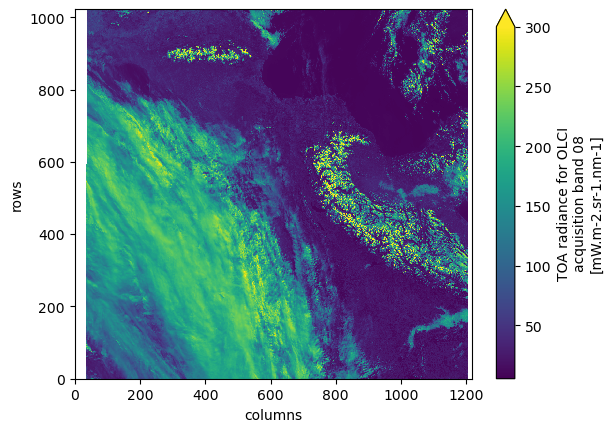

In [8]:
ds.oa08_radiance[::4, ::4].plot(vmax=300)

### Open Sentinel-3 OLCI L1 EFR as Dataset

The `xarray.DataTree` model was introduced in xarray v2024.10.0 (October 2024). To maintain compatibility with workflows based on `xr.Dataset`, the function `xarray.open_dataset(..., engine="eopf-zarr", op_mode="native")` is provided, which flattens the `DataTree` into a single dataset.

During this process, hierarchical groups in the Zarr product are merged, and variable as well as dimension names are prefixed with their group paths (using `_` by default) to ensure uniqueness. For example, `measurements/oa08_radiance` becomes `measurements_oa08_radiance`.


In [9]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
)
ds

<xarray.Dataset> Size: 8GB
Dimensions:                                                 (
                                                             conditions_geometry_rows: 4091,
                                                             conditions_geometry_columns: 77,
                                                             conditions_image_rows: 4091,
                                                             conditions_image_columns: 4865,
                                                             conditions_instrument_bands: 21,
                                                             ...
                                                             conditions_orphans_rows: 4091,
                                                             conditions_orphans_removed_pixels: 150,
                                                             measurements_rows: 4091,
                                                             measurements_columns: 4865,
                                                             quality_rows: 4091,
                                                             quality_columns: 4865)
Coordinates: (12/23)
    conditions_geometry_latitude                            (conditions_geometry_rows, conditions_geometry_columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
    conditions_geometry_longitude                           (conditions_geometry_rows, conditions_geometry_columns) float64 3MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
    conditions_image_time_stamp                             (conditions_image_rows) datetime64[ns] 33kB dask.array<chunksize=(1024,), meta=np.ndarray>
    conditions_image_altitude                               (conditions_image_rows, conditions_image_columns) int16 40MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    conditions_image_latitude                               (conditions_image_rows, conditions_image_columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    conditions_image_longitude                              (conditions_image_rows, conditions_image_columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    ...                                                      ...
    measurements_latitude                                   (measurements_rows, measurements_columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements_longitude                                  (measurements_rows, measurements_columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    quality_time_stamp                                      (quality_rows) datetime64[ns] 33kB dask.array<chunksize=(1024,), meta=np.ndarray>
    quality_altitude                                        (quality_rows, quality_columns) int16 40MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    quality_latitude                                        (quality_rows, quality_columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    quality_longitude                                       (quality_rows, quality_columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Dimensions without coordinates: conditions_geometry_rows,
                                conditions_geometry_columns,
                                conditions_image_rows,
                                conditions_image_columns,
                                conditions_instrument_bands,
                                conditions_instrument_bands2,
                                conditions_meteorology_rows,
                                conditions_meteorology_columns,
                                conditions_orphans_rows, measurements_rows,
                                measurements_columns, quality_rows,
                                quality_columns
Data variables: (12/63)
    conditions_geometry_oaa                                 (conditions_geometry_rows,

The separator character used in flattened variable names can be customized via the `group_sep` parameter. Additionally, you can filter the returned variables using the `variables` keyword argument, which accepts a string, an iterable of names, or a regular expression (regex) pattern.

In [10]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
    group_sep="/",
    variables="measurements*.",
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:                     (measurements/rows: 4091,
                                 measurements/columns: 4865)
Dimensions without coordinates: measurements/rows, measurements/columns
Data variables: (12/21)
    measurements/oa01_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa02_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa03_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa04_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa05_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa06_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    ...                          ...
    measurements/oa16_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa17_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa18_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa19_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa20_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    measurements/oa21_radiance  (measurements/rows, measurements/columns) float64 159MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (3)

Also here, we can plot one spectral band as an example.

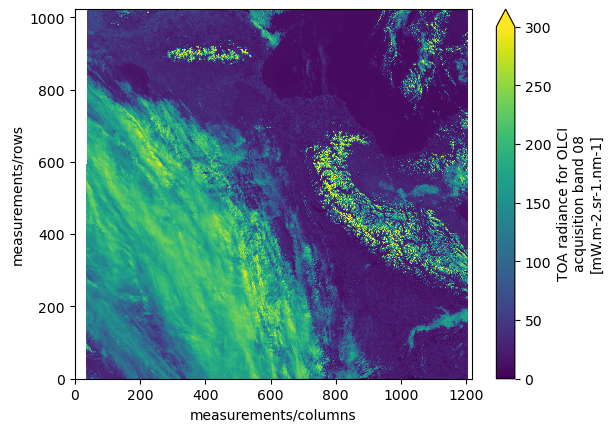

In [11]:
ds["measurements/oa08_radiance"][::4, ::4].plot(vmin=0., vmax=300.)

---

## Open a Sentinel-3 OLCI L1 ERR

We now access a Sentinel-3 OLCI L1 ERR product in **native mode**. The data access methods shown above apply equally to Sentinel-3 OLCI L1 EFR.

### Find a Sentinel-3 OLCI L1 ERR Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-olci-l1-err) to search for available Sentinel-3 OLCI L1 ERR tiles.

In [12]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l1-err"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-13", "2026-03-13"],
    ).items()
)
items

[<Item id=S3B_OL_1_ERR____20260313T095241_20260313T103636_20260314T095142_2635_117_350______ESA_O_NT_004>,
 <Item id=S3B_OL_1_ERR____20260313T095241_20260313T103636_20260313T121631_2635_117_350______ESA_O_NR_004>]

In [13]:
item = items[0]
item

<Item id=S3B_OL_1_ERR____20260313T095241_20260313T103636_20260314T095142_2635_117_350______ESA_O_NT_004>

### Open Sentinel-3 OLCI L1 ERR as DataTree

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [14]:
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:    (rows: 14974, columns: 77)
│   │       Coordinates:
│   │           latitude   (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           longitude  (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           oaa        (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           oza        (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           saa        (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   │           sza        (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│   ├── Group: /conditions/image
│   │       Dimensions:         (rows: 14974, columns: 1217)
│   │       Coordinates:
│   │           time_stamp      (rows) datetime64[ns] 120kB dask.array<chunksize=(1024,), meta=np.ndarray>
│   │           altitude        (rows, columns) int16 36MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │           latitude        (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │           longitude       (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │       Dimensions without coordinates: rows, columns
│   │       Data variables:
│   │           detector_index  (rows, columns) float32 73MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   │           frame_offset    (rows, columns) float32 73MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
│   ├── Group: /conditions/instrument
│   │       Dimensions:                       (bands: 21, detectors: 3700, bands2: 21)
│   │       Coordinates:
│   │         * detectors                     (detectors) int64 30kB 0 1 2 ... 3698 3699
│   │       Dimensions without coordinates: bands, bands2
│   │       Data variables:
│   │           fwhm                          (bands, detectors) float32 311kB dask.array<chunksize=(21, 3700), meta=np.ndarray>
│   │           lambda0                       (bands, detectors) float32 311kB dask.array<chunksize=(21, 3700), meta=np.ndarray>
│   │           relative_spectral_covariance  (bands, bands2) float32 2kB dask.array<chunksize=(21, 21), meta=np.ndarray>
│   │           solar_flux                    (bands, detectors) float32 311kB dask.array<chunksize=(21, 3700), meta=np.ndarray>
│   └── Group: /conditions/meteorology
│           Dimensions:                          (pressure_level: 25, rows: 14974,
│                                                 columns: 77, wind_vector: 2)
│           Coordinates:
│             * pressure_level                   (pressure_level) int64 200B 0 1 2 ... 23 24
│               latitude                         (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│               longitude                        (rows, columns) float64 9MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│             * wind_vector                      (wind_vector) int64 16B 0 1
│           Dimensions without coordinates: rows, columns
│           Data variables:
│               atmospheric_temperature_profile  (pressure_level, rows, columns) float32 115MB dask.array<chunksize=(7, 1024, 77), meta=np.ndarray>
│               horizontal_wind                  (wind_vector, rows, columns) float32 9MB dask.array<chunksize=(1, 1024, 77), meta=np.ndarray>
│               humidity                         (rows, columns) float32 5MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│               sea_level_pressure               (rows, columns) float32 5MB dask.array<chunksize=(1024, 77), meta=np.ndarray>
│               total_columnar_water_vapour      (rows, columns) float32 5MB dask.array<chunksize=(1024, 77

### Open Sentinel-3 OLCI L1 EFF Radiance Group as Dataset

We can directly access the individual reflectance group (`radianceData`) as `xarray.Dataset` objects. The opening parameters are stored in the asset’s extra field `"xarray:open_dataset_kwargs"`.

In [15]:
ds = xr.open_dataset(
    item.assets["radianceData"].href,
    **item.assets["radianceData"].extra_fields["xarray:open_dataset_kwargs"]
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:        (rows: 14974, columns: 1217)
Coordinates:
    time_stamp     (rows) datetime64[ns] 120kB dask.array<chunksize=(1024,), meta=np.ndarray>
    altitude       (rows, columns) int16 36MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    latitude       (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    longitude      (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Dimensions without coordinates: rows, columns
Data variables: (12/21)
    oa01_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa02_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa03_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa04_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa05_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa06_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    ...             ...
    oa16_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa17_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa18_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa19_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa20_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    oa21_radiance  (rows, columns) float64 146MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>

As an example, we plot the **red band** (`oa08_radiance`), which will trigger loading and visualization of the data. We also plot the 2D **curvilinear latitude and longitude grids**, which can be used for geolocation. Note that one product spanns half an orbit.

> **Note:** To speed up rendering of large datasets in Matplotlib, we plot the data at a lower resolution (every 4th pixel along-track).

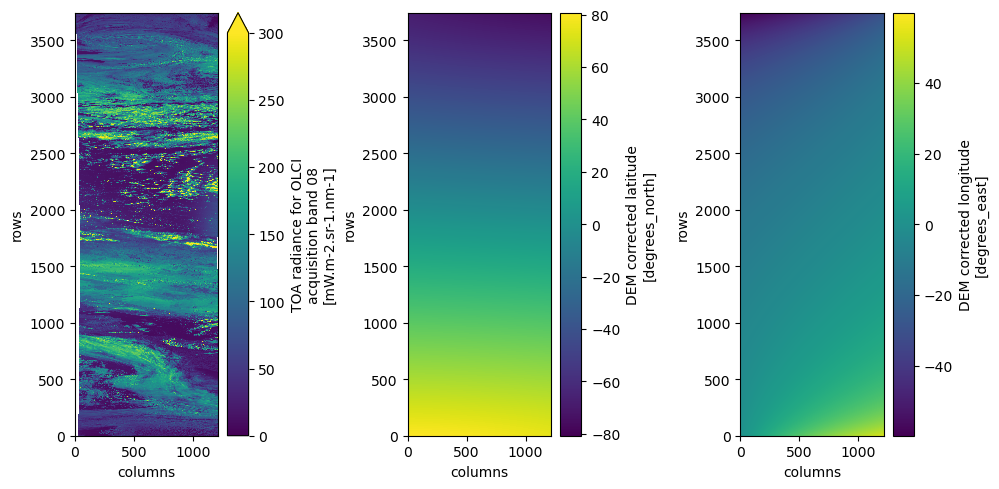

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ds.oa08_radiance[::4, :].plot.imshow(ax=ax[0], vmin=0, vmax=300)
ds.latitude[::4, :].plot.imshow(ax=ax[1], cmap="viridis")
ds.longitude[::4, :].plot.imshow(ax=ax[2], cmap="viridis")
plt.tight_layout()

## Open a Sentinel-3 SLSTR Level-2 LST

We now access a Sentinel-3 SLSTR Level-2 LST product in **native mode**. The data access methods shown above apply equally to Sentinel-3 SLSTR Level-2 LST.

### Find a Sentinel-3 SLSTR Level-2 LST Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst) to search for a Sentinel-3 SLSTR Level-2 LST tile.

In [17]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-3-slstr-l2-lst"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=["2026-03-13", "2026-03-13"],
    ).items()
)
items

[<Item id=S3B_SL_2_LST____20260313T212343_20260313T212643_20260313T235949_0179_117_357_0720_ESA_O_NR_004>,
 <Item id=S3B_SL_2_LST____20260313T212343_20260313T212643_20260315T051508_0179_117_357_0720_ESA_O_NT_004>,
 <Item id=S3B_SL_2_LST____20260313T100048_20260313T100348_20260314T174003_0180_117_350_2160_ESA_O_NT_004>]

In [18]:
item = items[0]
item

<Item id=S3B_SL_2_LST____20260313T212343_20260313T212643_20260313T235949_0179_117_357_0720_ESA_O_NR_004>

### Open Sentinel-3 SLSTR Level-2 LST as DataTree

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [19]:
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/auxiliary
│   │   │   Dimensions:     (rows: 1200, columns: 1500, nval: 256)
│   │   │   Dimensions without coordinates: rows, columns, nval
│   │   │   Data variables:
│   │   │       biome       (rows, columns) uint8 2MB dask.array<chunksize=(601, 750), meta=np.ndarray>
│   │   │       elevation   (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
│   │   │       fraction    (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
│   │   │       ndvi        (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
│   │   │       tcwv        (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
│   │   │       validation  (nval) int8 256B dask.array<chunksize=(256,), meta=np.ndarray>
│   │   └── Group: /conditions/auxiliary/orphan
│   │           Dimensions:    (rows: 1200, orphan_pixels: 187)
│   │           Dimensions without coordinates: rows, orphan_pixels
│   │           Data variables:
│   │               biome      (rows, orphan_pixels) uint8 224kB dask.array<chunksize=(601, 187), meta=np.ndarray>
│   │               elevation  (rows, orphan_pixels) float64 2MB dask.array<chunksize=(601, 187), meta=np.ndarray>
│   │               fraction   (rows, orphan_pixels) float64 2MB dask.array<chunksize=(601, 187), meta=np.ndarray>
│   │               ndvi       (rows, orphan_pixels) float64 2MB dask.array<chunksize=(601, 187), meta=np.ndarray>
│   │               tcwv       (rows, orphan_pixels) float64 2MB dask.array<chunksize=(601, 187), meta=np.ndarray>
│   ├── Group: /conditions/geometry
│   │       Dimensions:           (rows: 1200, columns: 130)
│   │       Coordinates:
│   │         * rows              (rows) int64 10kB 0 1 2 3 4 5 ... 1195 1196 1197 1198 1199
│   │         * columns           (columns) int64 1kB 0 1 2 3 4 5 ... 125 126 127 128 129
│   │           latitude          (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           longitude         (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           x                 (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           y                 (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │       Data variables:
│   │           sat_azimuth_tn    (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           sat_path_tn       (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           sat_zenith_tn     (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           solar_azimuth_tn  (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           solar_path_tn     (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           solar_zenith_tn   (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   ├── Group: /conditions/meteorology
│   │       Dimensions:                       (rows: 1200, columns: 130, t_series: 5,
│   │                                          p_atmos: 25)
│   │       Coordinates:
│   │         * rows                          (rows) int64 10kB 0 1 2 3 ... 1197 1198 1199
│   │         * columns                       (columns) int64 1kB 0 1 2 3 ... 127 128 129
│   │           latitude                      (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           longitude                     (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           x                             (rows, columns) float64 1MB dask.array<chunksize=(600, 130), meta=np.ndarray>
│   │           y                             (rows, columns) float64 1MB dask.array<chunksize=(600, 130), m

### Open Sentinel-3 SLSTR Level-2 LST Group as Dataset

Similarly, we can directly access the individual LST group (`lst`) as `xarray.Dataset` objects.  

In [20]:
ds = xr.open_dataset(
    item.assets["lst"].href,
    engine="eopf-zarr", 
    op_mode="native",
    chunks={}
)
ds

<xarray.Dataset> Size: 72MB
Dimensions:    (rows: 1200, columns: 1500)
Coordinates:
  * rows       (rows) int64 10kB 0 1 2 3 4 5 6 ... 1194 1195 1196 1197 1198 1199
  * columns    (columns) int64 12kB 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
    latitude   (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
    longitude  (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
    x          (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
    y          (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>
Data variables:
    lst        (rows, columns) float64 14MB dask.array<chunksize=(601, 750), meta=np.ndarray>

And we can plot the LST array along with the 2D latitude and longitude grids. 

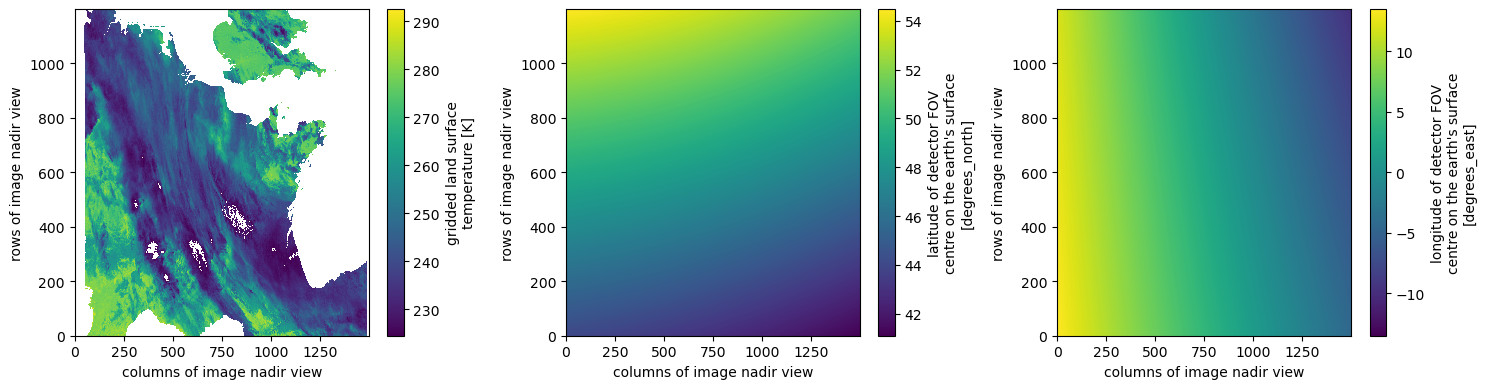

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ds.lst.plot.imshow(ax=ax[0])
ds.latitude.plot.imshow(ax=ax[1], cmap="viridis")
ds.longitude.plot.imshow(ax=ax[2], cmap="viridis")
plt.tight_layout()

Other Sentinel-3 products can be accessed using the same approach and are therefore not shown here in detail.

---

## Conclusion

This notebook demonstrates how to access Sentinel-3 EOPF Zarr samples in **native mode** using the **xarray-eopf** plugin. Key takeaways are:

- Access all Sentinel-3 products using hte same methods.  
- Open the full Zarr store as an `xr.DataTree` using `xr.open_dataset` and the asset `"product"`.  
- Open subgroups (e.g., `radianceData`, `lst`) as `xr.Dataset` using `xr.open_dataset`.  
- Open the full Zarr store as a flattened `xr.Dataset` using `xr.open_dataset` and the asset `"product"`.  
- Filter variables using the `variables` keyword argument.
- Opening parameters are integrated in STAC assets.

> Note: This notebook only covers the **native mode**, which presents the data as close as possible to the original product.  
> For an **analysis-ready view**, see the [Sentinel-3 analysis mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_3_analysis/).

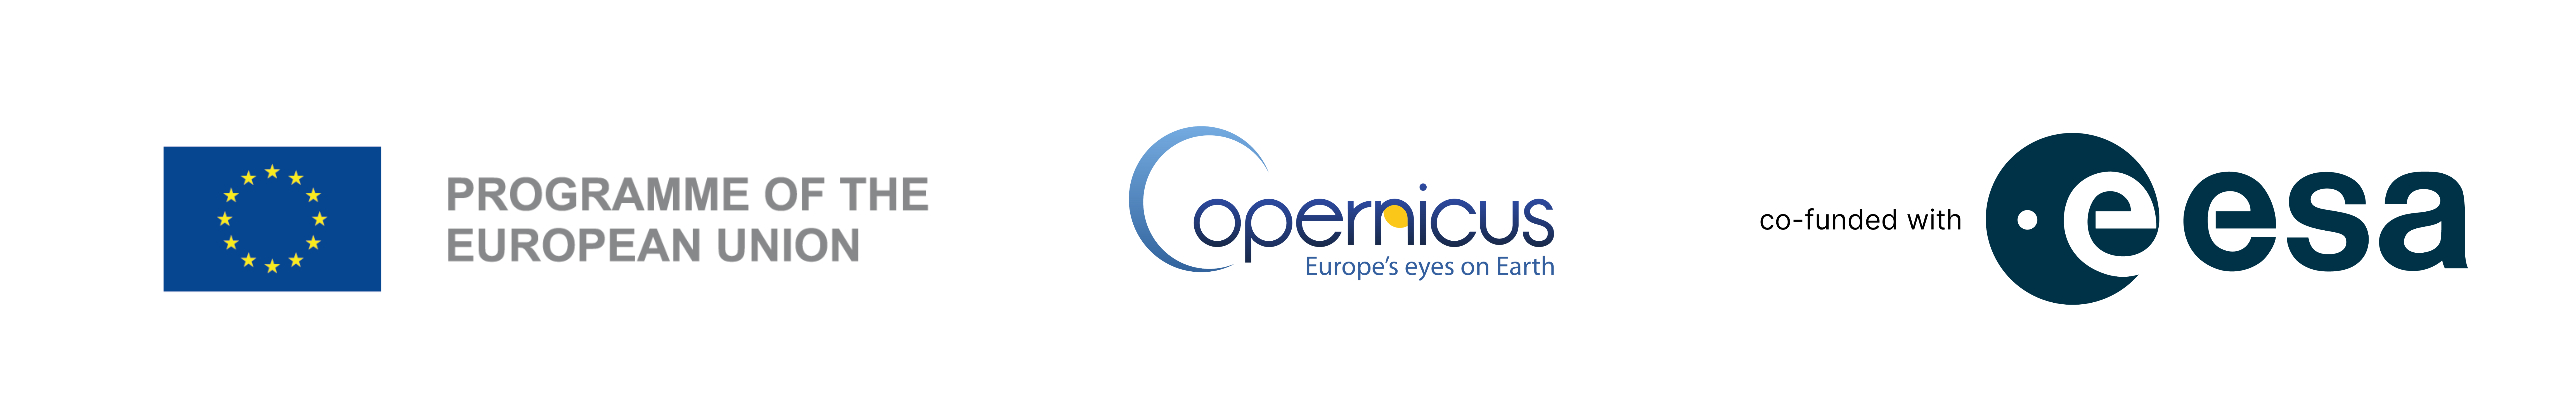